Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_48/tsm-sc-000/node1/stellar-core.log
  nodes=48, stable_tput=2160.00 txns/s, stable_avg_latency=87.05 ms, stable_median_latency=28.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_32/tsm-sc-000/node1/stellar-core.log
  nodes=32, stable_tput=3773.33 txns/s, stable_avg_latency=28.48 ms, stable_median_latency=20.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_16/tsm-sc-000/node1/stellar-core.log
  nodes=16, stable_tput=10650.00 txns/s, stable_avg_latency=8.54 ms, stable_median_latency=8.00 ms
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_8/tsm-sc-000/node1/stellar-core.log
Processing leader log: ../work/experiments/shabdiz/shabdiz_tplat_4/tsm-sc-000/node1/stellar-core.log
  nodes=4, stable_tput=30890.00 txns/s, stable_avg_latency=2.58 ms, stable_median_latency=2.00 ms

Summary:
   num_nodes  stable_avg_throughput_tps  stable_avg_latency_ms  \
0         48       

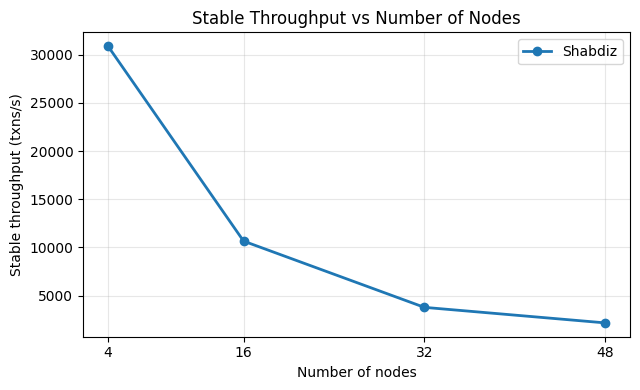

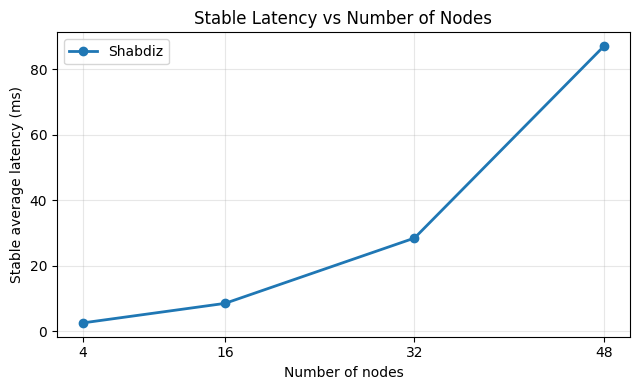

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np
from pathlib import Path

# Leader logs, one per node-count experiment.
log_file_list = [
    "../work/experiments/shabdiz/shabdiz_tplat_48/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_32/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_16/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_8/tsm-sc-000/node1/stellar-core.log",
    "../work/experiments/shabdiz/shabdiz_tplat_4/tsm-sc-000/node1/stellar-core.log",
]

# Stable window from the end of the experiment.
AVG_WINDOW_START_FROM_END = 60
AVG_WINDOW_END_FROM_END = 30

TS = r"(?P<ts>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3})"

# ============================================================
# Leader-side proposal patterns only.
# Latency start = leader proposal-send time.
# ============================================================
propose_patterns = [
    ("fast-send", re.compile(
        TS + r".*\[FAST SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    ("slow-send", re.compile(
        TS + r".*\[SLOW SEND PROPOSE\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+).*txns=(?P<txns>\d+)"
    )),

    ("send-very-old", re.compile(
        TS + r".*prop\(\): .*proposing block (?P<block>\w+) in view (?P<view>\d+)"
    )),
]

# ============================================================
# Leader-side commit patterns only.
# Throughput and latency end = leader commit time.
# ============================================================
commit_patterns = [
    ("shabdiz", re.compile(
        TS + r".*\[FAST COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("shabdiz-renamed", re.compile(
        TS + r".*\[SHABDIZ COMMITTED\] block=(?P<block>[0-9a-fA-F]+) view=(?P<view>\d+) txns=(?P<txns>\d+)"
    )),

    ("iths", re.compile(
        TS + r".*\[IT-HS\] Committed block (?P<block>[0-9a-fA-F]+) view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),

    ("old", re.compile(
        TS + r".*Committed block (?P<block>\w+) at view (?P<view>\d+) with (?P<txns>\d+) transactions"
    )),
]

# Used only to label slow-path views.
collect_patterns = [
    re.compile(TS + r".*Received COLLECT for view (?P<view>\d+)"),
    re.compile(TS + r".*Leader initiating COLLECT for view (?P<view>\d+)"),
]

def parse_ts(ts_str):
    return datetime.strptime(ts_str, "%Y-%m-%dT%H:%M:%S.%f")

def match_tagged(patterns, line):
    for tag, pat in patterns:
        m = pat.search(line)
        if m:
            return tag, m
    return None, None

def match_any(patterns, line):
    for pat in patterns:
        m = pat.search(line)
        if m:
            return m
    return None

def pick_window(values, start_from_end, end_from_end):
    values = np.asarray(values)

    if len(values) == 0:
        return values

    if len(values) >= start_from_end:
        return values[-start_from_end:-end_from_end]

    return values

def infer_num_nodes(log_file):
    """
    Extracts node count from paths like:
    shabdiz_tplat_48/...
    shabdiz_tplat_32/...
    """
    m = re.search(r"tplat_(\d+)", log_file)
    if m:
        return int(m.group(1))

    m = re.search(r"_(\d+)/tsm-sc-", log_file)
    if m:
        return int(m.group(1))

    return None

def parse_one_leader_log(log_file):
    propose_times = {}
    propose_sources = {}

    commit_times = {}
    batch_sizes = {}
    commit_sources = {}

    collect_views = set()
    slow_proposal_views = set()

    with open(log_file, errors="ignore") as f:
        for line in f:
            collect_match = match_any(collect_patterns, line)
            if collect_match:
                view = int(collect_match.group("view"))
                collect_views.add(view)
                continue

            ptag, pmatch = match_tagged(propose_patterns, line)
            if pmatch:
                ts = parse_ts(pmatch.group("ts"))
                block = pmatch.group("block")
                view = int(pmatch.group("view"))
                key = (block, view)

                if ptag == "slow-send":
                    slow_proposal_views.add(view)

                if key not in propose_times or ts < propose_times[key]:
                    propose_times[key] = ts
                    propose_sources[key] = ptag

                continue

            ctag, cmatch = match_tagged(commit_patterns, line)
            if cmatch:
                ts = parse_ts(cmatch.group("ts"))
                block = cmatch.group("block")
                view = int(cmatch.group("view"))
                txns = int(cmatch.group("txns"))
                key = (block, view)

                if key not in commit_times or ts < commit_times[key]:
                    commit_times[key] = ts
                    batch_sizes[key] = txns
                    commit_sources[key] = ctag

                continue

    if not commit_times:
        return {
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "No commits found",
            "leader_proposals_matched": len(propose_times),
            "leader_commits_matched": 0,
        }

    commit_rows = []
    latency_rows = []

    for key, ctime in sorted(commit_times.items(), key=lambda x: x[1]):
        block, view = key
        txns = batch_sizes.get(key, 1)

        path = "slow" if (view in collect_views or view in slow_proposal_views) else "fast"

        commit_rows.append({
            "block": block,
            "view": view,
            "commit_time": ctime,
            "txn_count": txns,
            "path": path,
            "commit_source": commit_sources.get(key, "unknown"),
        })

        if key not in propose_times:
            continue

        ptime = propose_times[key]
        latency_sec = (ctime - ptime).total_seconds()

        if latency_sec < 0:
            continue

        latency_rows.append({
            "block": block,
            "view": view,
            "propose_time": ptime,
            "commit_time": ctime,
            "latency_sec": latency_sec,
            "latency_ms": latency_sec * 1000.0,
            "txn_count": txns,
            "path": path,
            "proposal_source": propose_sources.get(key, "unknown"),
            "commit_source": commit_sources.get(key, "unknown"),
        })

    commit_df = pd.DataFrame(commit_rows)
    lat_df = pd.DataFrame(latency_rows)

    # Time origin: first leader proposal or commit.
    all_times = list(commit_df["commit_time"])
    if not lat_df.empty:
        all_times += list(lat_df["propose_time"])

    start_time = min(all_times)

    commit_df["time_sec"] = (commit_df["commit_time"] - start_time).dt.total_seconds()
    commit_df["time_sec_floor"] = np.floor(commit_df["time_sec"]).astype(int)

    # Throughput per second.
    throughput_series = commit_df.groupby("time_sec_floor")["txn_count"].sum()

    full_tput_index = np.arange(
        int(throughput_series.index.min()),
        int(throughput_series.index.max()) + 1
    )
    throughput_series = throughput_series.reindex(full_tput_index, fill_value=0)

    tput_window = pick_window(
        throughput_series.values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    stable_avg_tput = np.mean(tput_window) if len(tput_window) > 0 else np.nan

    # Latency per second.
    if not lat_df.empty:
        lat_df["time_sec"] = (lat_df["commit_time"] - start_time).dt.total_seconds()
        lat_df["time_sec_floor"] = np.floor(lat_df["time_sec"]).astype(int)

        latency_series_mean = lat_df.groupby("time_sec_floor")["latency_ms"].mean()
        latency_series_median = lat_df.groupby("time_sec_floor")["latency_ms"].median()

        full_lat_index = np.arange(
            int(latency_series_mean.index.min()),
            int(latency_series_mean.index.max()) + 1
        )

        latency_series_mean = latency_series_mean.reindex(full_lat_index, fill_value=np.nan)
        latency_series_median = latency_series_median.reindex(full_lat_index, fill_value=np.nan)

        mean_lat_window = pick_window(
            latency_series_mean.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        median_lat_window = pick_window(
            latency_series_median.values,
            AVG_WINDOW_START_FROM_END,
            AVG_WINDOW_END_FROM_END,
        )

        stable_avg_latency_ms = np.nanmean(mean_lat_window)
        stable_median_latency_ms = np.nanmedian(median_lat_window)

        overall_avg_latency_ms = lat_df["latency_ms"].mean()
        overall_median_latency_ms = lat_df["latency_ms"].median()
        overall_p95_latency_ms = lat_df["latency_ms"].quantile(0.95)
        overall_p99_latency_ms = lat_df["latency_ms"].quantile(0.99)
    else:
        stable_avg_latency_ms = np.nan
        stable_median_latency_ms = np.nan
        overall_avg_latency_ms = np.nan
        overall_median_latency_ms = np.nan
        overall_p95_latency_ms = np.nan
        overall_p99_latency_ms = np.nan

    commit_duration_sec = (
        commit_df["commit_time"].max() - commit_df["commit_time"].min()
    ).total_seconds()

    if commit_duration_sec > 0:
        overall_tput = commit_df["txn_count"].sum() / commit_duration_sec
    else:
        overall_tput = np.nan

    return {
        "num_nodes": infer_num_nodes(log_file),
        "log_file": log_file,
        "leader_proposals_matched": len(propose_times),
        "leader_commits_matched": len(commit_times),
        "latency_pairs_matched": len(lat_df),
        "total_committed_txns": int(commit_df["txn_count"].sum()),
        "committed_blocks": len(commit_df),
        "fast_blocks": int((commit_df["path"] == "fast").sum()),
        "slow_blocks": int((commit_df["path"] == "slow").sum()),
        "stable_avg_throughput_tps": stable_avg_tput,
        "overall_throughput_tps": overall_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_median_latency_ms": stable_median_latency_ms,
        "overall_avg_latency_ms": overall_avg_latency_ms,
        "overall_median_latency_ms": overall_median_latency_ms,
        "overall_p95_latency_ms": overall_p95_latency_ms,
        "overall_p99_latency_ms": overall_p99_latency_ms,
        "commit_duration_sec": commit_duration_sec,
        "error": None,
    }

# ============================================================
# Parse all logs.
# ============================================================
summaries = []

for log_file in log_file_list:
    print(f"Processing leader log: {log_file}")

    if not Path(log_file).exists():
        print(f"  WARNING: file not found: {log_file}")
        summaries.append({
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "file not found",
        })
        continue

    summary = parse_one_leader_log(log_file)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  nodes={summary['num_nodes']}, "
            f"stable_tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"stable_avg_latency={summary['stable_avg_latency_ms']:.2f} ms, "
            f"stable_median_latency={summary['stable_median_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

plot_df = summary_df.dropna(subset=[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df.sort_values("num_nodes")

print("\nSummary:")
print(summary_df[[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_median_latency_ms",
    "overall_p95_latency_ms",
    "overall_p99_latency_ms",
    "total_committed_txns",
    "committed_blocks",
    "fast_blocks",
    "slow_blocks",
    "error",
]])

if plot_df.empty:
    print("No valid results to plot.")
else:
    # ============================================================
    # Final plot 1: stable throughput vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        linewidth=2,
        label="Shabdiz",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable throughput (txns/s)")
    plt.title("Stable Throughput vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Final plot 2: stable latency vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_latency_ms"],
        marker="o",
        linewidth=2,
        label="Shabdiz",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable average latency (ms)")
    plt.title("Stable Latency vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Processing run: ../work/experiments/shabdiz/shab_tput_latency_8_clients_1_threads_1_inflight_100_total_threads_1_total_inflight_100
  Parsing client log: ../work/experiments/shabdiz/shab_tput_latency_8_clients_1_threads_1_inflight_100_total_threads_1_total_inflight_100/client_0.log
  aggregate_inflight=100, total_threads=1, client_logs=1, measurement_secs=120..179, stable_tput=14313.33 txns/s, stable_avg_latency=6.68 ms, stable_p99_latency=35.05 ms
Processing run: ../work/experiments/shabdiz/shab_tput_latency_8_clients_1_threads_1_inflight_150_total_threads_1_total_inflight_150
  Parsing client log: ../work/experiments/shabdiz/shab_tput_latency_8_clients_1_threads_1_inflight_150_total_threads_1_total_inflight_150/client_0.log
  aggregate_inflight=150, total_threads=1, client_logs=1, measurement_secs=120..179, stable_tput=15858.33 txns/s, stable_avg_latency=9.15 ms, stable_p99_latency=22.50 ms
Processing run: ../work/experiments/shabdiz/shab_tput_latency_8_clients_1_threads_2_inflight_1

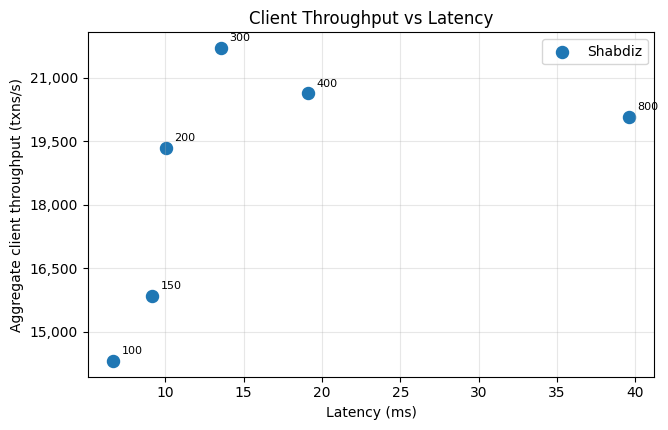

Saved: ../work/experiments/shabdiz/shab_tput_latency_vs_inflight.pdf


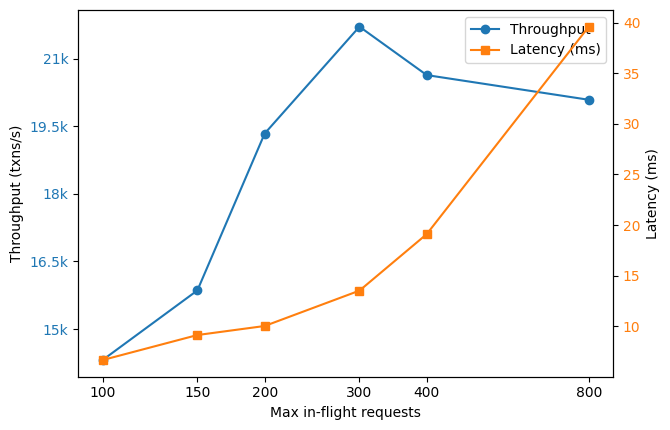

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import math
from pathlib import Path
from matplotlib.ticker import MaxNLocator, StrMethodFormatter, NullFormatter, FuncFormatter

# ============================================================
# Experiment config
# ============================================================

BASE_DIR = Path("../work/experiments/shabdiz")
NUM_NODES = 8

LOAD_POINTS = [
    {"active_clients": 1, "client_threads": 1, "max_in_flight": 100},   # total inflight 100
    {"active_clients": 1, "client_threads": 1, "max_in_flight": 150},   # total inflight 150
    {"active_clients": 1, "client_threads": 2, "max_in_flight": 100},   # total inflight 200
    {"active_clients": 1, "client_threads": 2, "max_in_flight": 150},   # total inflight 300
    {"active_clients": 1, "client_threads": 4, "max_in_flight": 100},   # total inflight 400
    {"active_clients": 1, "client_threads": 8, "max_in_flight": 100},   # total inflight 800
    # {"active_clients": 2, "client_threads": 8, "max_in_flight": 100},   # total inflight 1600
]

def expected_run_dir(load):
    active_clients = load["active_clients"]
    client_threads = load["client_threads"]
    max_in_flight = load["max_in_flight"]

    total_client_threads = active_clients * client_threads
    aggregate_max_in_flight = total_client_threads * max_in_flight

    return BASE_DIR / (
        f"shab_tput_latency_{NUM_NODES}_"
        f"clients_{active_clients}_"
        f"threads_{client_threads}_"
        f"inflight_{max_in_flight}_"
        f"total_threads_{total_client_threads}_"
        f"total_inflight_{aggregate_max_in_flight}"
    )

def fallback_old_run_dir(load):
    active_clients = load["active_clients"]
    client_threads = load["client_threads"]

    total_client_threads = active_clients * client_threads

    return BASE_DIR / (
        f"shab_tput_latency_{NUM_NODES}_"
        f"clients_{active_clients}_"
        f"threads_{client_threads}_"
        f"total_threads_{total_client_threads}"
    )

RUN_DIRS = []

for load in LOAD_POINTS:
    new_dir = expected_run_dir(load)
    old_dir = fallback_old_run_dir(load)

    if new_dir.exists():
        RUN_DIRS.append(new_dir)
    elif old_dir.exists():
        print(f"WARNING: using old-style folder name: {old_dir}")
        RUN_DIRS.append(old_dir)
    else:
        RUN_DIRS.append(new_dir)

# ============================================================
# Fixed measurement-window settings
# ============================================================

# Measure only seconds 120 through 179.
# This is a 60-second window: [120, 180).
MEASUREMENT_SEC_START = 120
MEASUREMENT_SEC_END_EXCLUSIVE = 180

# Drop low-throughput partial seconds inside the measurement window.
# Example: requests=0 or very low throughput seconds are removed.
MIN_THROUGHPUT_FRACTION_OF_MEDIAN = 0.50

# Options: "mean", "p50", "p99", "p999"
LATENCY_METRIC_FOR_PLOT = "mean"

SAVE_FIGURES = False
OUT_DIR = BASE_DIR

# ============================================================
# Regex for client logs
# ============================================================

client_sec_pattern = re.compile(
    r"\[CLIENT_SEC\]\s+"
    r"sec=(?P<sec>\d+)\s+"
    r"requests=(?P<requests>\d+)\s+"
    r"throughput=(?P<throughput>[0-9.]+)\s+"
    r"avg_latency_ms=(?P<avg_latency_ms>[0-9.]+|nan)\s+"
    r"p50_latency_ms=(?P<p50_latency_ms>[0-9.]+|nan)\s+"
    r"p99_latency_ms=(?P<p99_latency_ms>[0-9.]+|nan)"
    r"(?:\s+p999_latency_ms=(?P<p999_latency_ms>[0-9.]+|nan))?"
)

def parse_float_or_nan(x):
    if x is None or x == "nan":
        return np.nan
    return float(x)

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = ~np.isnan(values)

    if valid.sum() == 0:
        return np.nan

    values = values[valid]
    weights = weights[valid]

    if weights.sum() <= 0:
        return np.nan

    return np.average(values, weights=weights)

def parse_run_config(run_dir):
    config = {
        "num_nodes": None,
        "active_clients": None,
        "client_threads_per_vm": None,
        "total_client_threads": None,
        "client_max_in_flight_per_thread": None,
        "aggregate_max_in_flight": None,
        "client_duration_sec": None,
        "send_interval_us": None,
        "server_batch_size_hint": None,
    }

    config_path = Path(run_dir) / "run_config.txt"

    if config_path.exists():
        with open(config_path, errors="ignore") as f:
            for line in f:
                if "=" not in line:
                    continue

                key, value = line.strip().split("=", 1)

                if key in config:
                    try:
                        config[key] = int(value)
                    except ValueError:
                        config[key] = value

    name = Path(run_dir).name

    # New folder format:
    # shab_tput_latency_8_clients_1_threads_4_inflight_100_total_threads_4_total_inflight_400
    m = re.search(
        r"shab_tput_latency_(?P<num_nodes>\d+)_"
        r"clients_(?P<clients>\d+)_"
        r"threads_(?P<threads>\d+)_"
        r"inflight_(?P<inflight>\d+)_"
        r"total_threads_(?P<total_threads>\d+)_"
        r"total_inflight_(?P<total_inflight>\d+)",
        name,
    )

    if m:
        config["num_nodes"] = config["num_nodes"] or int(m.group("num_nodes"))
        config["active_clients"] = config["active_clients"] or int(m.group("clients"))
        config["client_threads_per_vm"] = config["client_threads_per_vm"] or int(m.group("threads"))
        config["client_max_in_flight_per_thread"] = (
            config["client_max_in_flight_per_thread"] or int(m.group("inflight"))
        )
        config["total_client_threads"] = (
            config["total_client_threads"] or int(m.group("total_threads"))
        )
        config["aggregate_max_in_flight"] = (
            config["aggregate_max_in_flight"] or int(m.group("total_inflight"))
        )

    # Old folder format:
    # shab_tput_latency_8_clients_1_threads_4_total_threads_4
    m_old = re.search(
        r"shab_tput_latency_(?P<num_nodes>\d+)_"
        r"clients_(?P<clients>\d+)_"
        r"threads_(?P<threads>\d+)_"
        r"total_threads_(?P<total_threads>\d+)",
        name,
    )

    if m_old:
        config["num_nodes"] = config["num_nodes"] or int(m_old.group("num_nodes"))
        config["active_clients"] = config["active_clients"] or int(m_old.group("clients"))
        config["client_threads_per_vm"] = config["client_threads_per_vm"] or int(m_old.group("threads"))
        config["total_client_threads"] = config["total_client_threads"] or int(m_old.group("total_threads"))

    # If run_config did not contain max-in-flight and folder is old-style,
    # infer from your current experiment setting: 100 per client thread.
    if config["client_max_in_flight_per_thread"] is None:
        config["client_max_in_flight_per_thread"] = 100

    if (
        config["aggregate_max_in_flight"] is None
        and config["total_client_threads"] is not None
        and config["client_max_in_flight_per_thread"] is not None
    ):
        config["aggregate_max_in_flight"] = (
            config["total_client_threads"]
            * config["client_max_in_flight_per_thread"]
        )

    return config

def parse_one_client_log(log_file, client_id):
    rows = []

    with open(log_file, errors="ignore") as f:
        for line in f:
            m = client_sec_pattern.search(line)
            if not m:
                continue

            rows.append({
                "client_id": client_id,
                "sec": int(m.group("sec")),
                "requests": int(m.group("requests")),
                "throughput_tps": float(m.group("throughput")),
                "avg_latency_ms": parse_float_or_nan(m.group("avg_latency_ms")),
                "p50_latency_ms": parse_float_or_nan(m.group("p50_latency_ms")),
                "p99_latency_ms": parse_float_or_nan(m.group("p99_latency_ms")),
                "p999_latency_ms": parse_float_or_nan(m.group("p999_latency_ms")),
            })

    return pd.DataFrame(rows)

def aggregate_clients_by_second(client_df):
    rows = []

    for sec, g in client_df.groupby("sec"):
        total_requests = int(g["requests"].sum())
        total_tput = float(g["throughput_tps"].sum())

        rows.append({
            "sec": sec,
            "requests": total_requests,
            "throughput_tps": total_tput,

            # Request-weighted mean latency across client logs.
            "avg_latency_ms": weighted_mean(
                g["avg_latency_ms"].values,
                g["requests"].values,
            ),

            # Approximate combined percentiles.
            # Exact global p50/p99 requires raw per-request latency samples.
            "p50_latency_ms": weighted_mean(
                g["p50_latency_ms"].values,
                g["requests"].values,
            ),
            "p99_latency_ms": weighted_mean(
                g["p99_latency_ms"].values,
                g["requests"].values,
            ),
            "p999_latency_ms": weighted_mean(
                g["p999_latency_ms"].values,
                g["requests"].values,
            ),
        })

    return pd.DataFrame(rows).sort_values("sec")

def select_stable_window(agg_df):
    if agg_df.empty:
        return agg_df.copy(), {
            "measurement_sec_start": MEASUREMENT_SEC_START,
            "measurement_sec_end_exclusive": MEASUREMENT_SEC_END_EXCLUSIVE,
            "median_tput_before_filter": np.nan,
            "min_valid_tput": np.nan,
            "valid_seconds_before_window": 0,
        }

    # Use fixed measurement interval: [120, 180)
    df = agg_df[
        (agg_df["sec"] >= MEASUREMENT_SEC_START)
        & (agg_df["sec"] < MEASUREMENT_SEC_END_EXCLUSIVE)
    ].copy()

    if df.empty:
        return df, {
            "measurement_sec_start": MEASUREMENT_SEC_START,
            "measurement_sec_end_exclusive": MEASUREMENT_SEC_END_EXCLUSIVE,
            "median_tput_before_filter": np.nan,
            "min_valid_tput": np.nan,
            "valid_seconds_before_window": 0,
        }

    # Remove zero-request seconds.
    df = df[df["requests"] > 0].copy()

    if df.empty:
        return df, {
            "measurement_sec_start": MEASUREMENT_SEC_START,
            "measurement_sec_end_exclusive": MEASUREMENT_SEC_END_EXCLUSIVE,
            "median_tput_before_filter": np.nan,
            "min_valid_tput": np.nan,
            "valid_seconds_before_window": 0,
        }

    median_tput = df["throughput_tps"].median()
    min_valid_tput = median_tput * MIN_THROUGHPUT_FRACTION_OF_MEDIAN
    valid_seconds_before_window = len(df)

    # Remove unusually low-throughput partial/drain seconds inside the fixed interval.
    df = df[df["throughput_tps"] >= min_valid_tput].copy()

    if df.empty:
        return df, {
            "measurement_sec_start": MEASUREMENT_SEC_START,
            "measurement_sec_end_exclusive": MEASUREMENT_SEC_END_EXCLUSIVE,
            "median_tput_before_filter": median_tput,
            "min_valid_tput": min_valid_tput,
            "valid_seconds_before_window": valid_seconds_before_window,
        }

    return df, {
        "measurement_sec_start": MEASUREMENT_SEC_START,
        "measurement_sec_end_exclusive": MEASUREMENT_SEC_END_EXCLUSIVE,
        "median_tput_before_filter": median_tput,
        "min_valid_tput": min_valid_tput,
        "valid_seconds_before_window": valid_seconds_before_window,
    }

def summarize_one_run(run_dir):
    run_dir = Path(run_dir)
    config = parse_run_config(run_dir)

    if not run_dir.exists():
        return {
            "run_dir": str(run_dir),
            "run_name": run_dir.name,
            "error": "run directory not found",
            **config,
        }

    client_logs = sorted(run_dir.glob("client_*.log"))

    if not client_logs:
        old_client_log = run_dir / "client.log"
        if old_client_log.exists():
            client_logs = [old_client_log]

    if not client_logs:
        return {
            "run_dir": str(run_dir),
            "run_name": run_dir.name,
            "error": "no client_*.log files found",
            **config,
        }

    client_dfs = []

    for idx, log_file in enumerate(client_logs):
        print(f"  Parsing client log: {log_file}")

        df = parse_one_client_log(log_file, client_id=idx)

        if df.empty:
            print(f"    WARNING: no [CLIENT_SEC] lines found in {log_file}")
            continue

        client_dfs.append(df)

    if not client_dfs:
        return {
            "run_dir": str(run_dir),
            "run_name": run_dir.name,
            "error": "no [CLIENT_SEC] lines found in any client log",
            "num_client_logs": len(client_logs),
            **config,
        }

    raw_client_df = pd.concat(client_dfs, ignore_index=True)
    agg_df = aggregate_clients_by_second(raw_client_df)

    stable_df, filter_info = select_stable_window(agg_df)

    if stable_df.empty:
        return {
            "run_dir": str(run_dir),
            "run_name": run_dir.name,
            "error": "no seconds in fixed measurement window after filtering",
            "num_client_logs": len(client_logs),
            **config,
            **filter_info,
        }

    total_requests_all = int(agg_df["requests"].sum())
    total_requests_stable = int(stable_df["requests"].sum())

    stable_avg_tput = stable_df["throughput_tps"].mean()

    stable_avg_latency_ms = weighted_mean(
        stable_df["avg_latency_ms"].values,
        stable_df["requests"].values,
    )
    stable_p50_latency_ms = weighted_mean(
        stable_df["p50_latency_ms"].values,
        stable_df["requests"].values,
    )
    stable_p99_latency_ms = weighted_mean(
        stable_df["p99_latency_ms"].values,
        stable_df["requests"].values,
    )
    stable_p999_latency_ms = weighted_mean(
        stable_df["p999_latency_ms"].values,
        stable_df["requests"].values,
    )

    nonzero_df = agg_df[agg_df["requests"] > 0].copy()

    return {
        "run_dir": str(run_dir),
        "run_name": run_dir.name,
        "num_client_logs": len(client_logs),

        **config,
        **filter_info,

        "seconds_total": len(agg_df),
        "seconds_nonzero": len(nonzero_df),
        "seconds_stable_used": len(stable_df),
        "stable_sec_start": int(stable_df["sec"].min()),
        "stable_sec_end": int(stable_df["sec"].max()),

        "total_client_acked_requests_all": total_requests_all,
        "total_client_acked_requests_stable": total_requests_stable,

        "stable_avg_throughput_tps": stable_avg_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_p50_latency_ms": stable_p50_latency_ms,
        "stable_p99_latency_ms": stable_p99_latency_ms,
        "stable_p999_latency_ms": stable_p999_latency_ms,

        "overall_avg_throughput_tps_nonzero": nonzero_df["throughput_tps"].mean(),
        "overall_avg_latency_ms_nonzero": weighted_mean(
            nonzero_df["avg_latency_ms"].values,
            nonzero_df["requests"].values,
        ),

        "error": None,
    }

# ============================================================
# Parse all run directories
# ============================================================

summaries = []

for run_dir in RUN_DIRS:
    print(f"Processing run: {run_dir}")

    summary = summarize_one_run(run_dir)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  aggregate_inflight={summary['aggregate_max_in_flight']}, "
            f"total_threads={summary['total_client_threads']}, "
            f"client_logs={summary['num_client_logs']}, "
            f"measurement_secs={summary['stable_sec_start']}..{summary['stable_sec_end']}, "
            f"stable_tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"stable_avg_latency={summary['stable_avg_latency_ms']:.2f} ms, "
            f"stable_p99_latency={summary['stable_p99_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

# ============================================================
# Print and save summary
# ============================================================

print("\nSummary:")

cols_to_print = [
    "aggregate_max_in_flight",
    "total_client_threads",
    "active_clients",
    "client_threads_per_vm",
    "client_max_in_flight_per_thread",
    "num_client_logs",
    "measurement_sec_start",
    "measurement_sec_end_exclusive",
    "stable_sec_start",
    "stable_sec_end",
    "seconds_stable_used",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_p50_latency_ms",
    "stable_p99_latency_ms",
    "stable_p999_latency_ms",
    "total_client_acked_requests_all",
    "total_client_acked_requests_stable",
    "median_tput_before_filter",
    "min_valid_tput",
    "error",
]

existing_cols = [c for c in cols_to_print if c in summary_df.columns]
print(summary_df[existing_cols])

summary_csv = OUT_DIR / "shab_tput_latency_summary.csv"
# summary_df.to_csv(summary_csv, index=False)
print(f"\nSaved summary CSV to: {summary_csv}")

# ============================================================
# Plot helpers
# ============================================================

plot_df = summary_df.dropna(subset=[
    "aggregate_max_in_flight",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df[plot_df["error"].isna()].copy()
plot_df = plot_df.sort_values("aggregate_max_in_flight")

def set_pretty_y_axis(ax, nbins=8):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

def set_pretty_latency_y_axis(ax, nbins=8):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.1f}"))

def set_log_inflight_x_axis(ax, plot_df):
    xticks = sorted(plot_df["aggregate_max_in_flight"].astype(int).unique())

    ax.set_xscale("log", base=2)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])
    ax.xaxis.set_minor_formatter(NullFormatter())

def format_3_sigfig_compact(x, pos=None):
    if x == 0:
        return "0"

    if not math.isfinite(x):
        return ""

    abs_x = abs(x)

    if abs_x >= 1_000_000:
        return f"{x / 1_000_000:.3g}M"

    if abs_x >= 1_000:
        return f"{x / 1_000:.3g}k"

    return f"{x:.3g}"

def set_3_sigfig_y_axis(ax, nbins=8):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
    ax.yaxis.set_major_formatter(FuncFormatter(format_3_sigfig_compact))

# ============================================================
# Plot
# ============================================================

if plot_df.empty:
    print("No valid client-side points to plot.")
else:
    if LATENCY_METRIC_FOR_PLOT == "mean":
        latency_col = "stable_avg_latency_ms"
        latency_label = "Latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "p50":
        latency_col = "stable_p50_latency_ms"
        latency_label = "Client p50 latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "p99":
        latency_col = "stable_p99_latency_ms"
        latency_label = "Client p99 latency (ms)"
    elif LATENCY_METRIC_FOR_PLOT == "p999":
        latency_col = "stable_p999_latency_ms"
        latency_label = "Client p99.9 latency (ms)"
    else:
        raise ValueError(f"Unknown LATENCY_METRIC_FOR_PLOT={LATENCY_METRIC_FOR_PLOT}")

    # ------------------------------------------------------------
    # Plot 1: Throughput vs latency
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6.8, 4.4))

    ax.scatter(
        plot_df[latency_col],
        plot_df["stable_avg_throughput_tps"],
        s=75,
        label="Shabdiz",
    )

    for idx, row in plot_df.iterrows():
        ax.annotate(
            f"{int(row['aggregate_max_in_flight'])}",
            (row[latency_col], row["stable_avg_throughput_tps"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=8,
        )

    ax.set_xlabel(latency_label)
    ax.set_ylabel("Aggregate client throughput (txns/s)")
    ax.set_title("Client Throughput vs Latency")
    ax.grid(True, alpha=0.3)
    ax.legend()
    set_pretty_y_axis(ax, nbins=8)

    plt.tight_layout()

    out_path = OUT_DIR / "shab_tput_vs_latency.png"
    if SAVE_FIGURES:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")

    plt.show()

    # ------------------------------------------------------------
    # Combined Plot: Throughput + Latency vs aggregate in-flight
    # Left y-axis  -> Throughput
    # Right y-axis -> Latency
    # ------------------------------------------------------------

    fig, ax1 = plt.subplots(figsize=(6.8, 4.4))

    throughput_color = "tab:blue"
    latency_color = "tab:orange"

    # Left axis: throughput
    line1 = ax1.plot(
        plot_df["aggregate_max_in_flight"],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        color=throughput_color,
        label="Throughput",
    )

    set_log_inflight_x_axis(ax1, plot_df)
    set_3_sigfig_y_axis(ax1, nbins=8)

    ax1.set_xlabel("Max in-flight requests")
    ax1.set_ylabel("Throughput (txns/s)")
    ax1.tick_params(axis="y", labelcolor=throughput_color)

    # Right axis: latency
    ax2 = ax1.twinx()

    line2 = ax2.plot(
        plot_df["aggregate_max_in_flight"],
        plot_df[latency_col],
        marker="s",
        color=latency_color,
        label=latency_label,
    )

    set_3_sigfig_y_axis(ax2, nbins=8)

    ax2.set_ylabel(latency_label)
    ax2.tick_params(axis="y", labelcolor=latency_color)

    # Combined legend
    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    # Optional grid
    # ax1.grid(True, alpha=0.3, which="both")

    plt.tight_layout()

    out_path = OUT_DIR / "shab_tput_latency_vs_inflight.pdf"
    if SAVE_FIGURES:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")

    plt.show()

Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_4/tsm-sc-000/node1/stellar-core.log
  nodes=4, stable_tput=23470.00 txns/s, stable_avg_latency=3.61 ms, stable_median_latency=3.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_8/tsm-sc-000/node1/stellar-core.log
  nodes=8, stable_tput=18410.00 txns/s, stable_avg_latency=4.72 ms, stable_median_latency=4.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_16/tsm-sc-000/node1/stellar-core.log
  nodes=16, stable_tput=9410.00 txns/s, stable_avg_latency=9.98 ms, stable_median_latency=9.00 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_32/tsm-sc-000/node1/stellar-core.log
  nodes=32, stable_tput=3893.33 txns/s, stable_avg_latency=25.82 ms, stable_median_latency=21.50 ms
Processing IT-HotStuff leader log: ../work/experiments/shabdiz/ITHS_tplat_48/tsm-sc-000/node1/stellar-core.log
  nodes=48, stable_tput=1576.67 txns/s, stable_avg_la

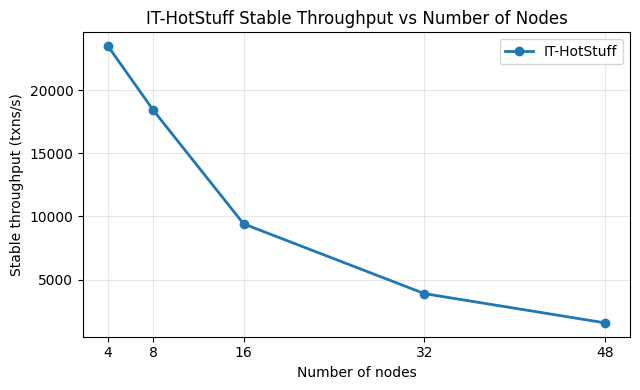

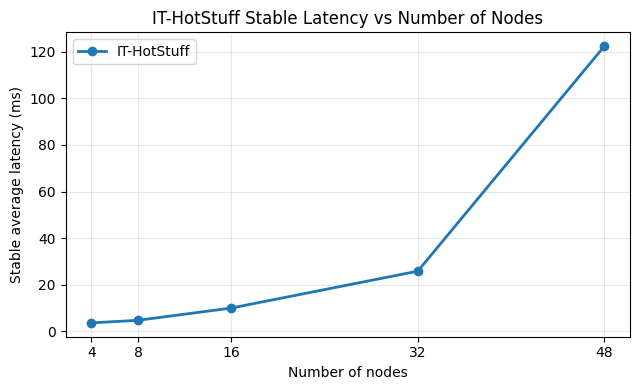

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from pathlib import Path

# Client logs, one per node-count experiment.
log_file_list = [
    "../work/experiments/shabdiz/ITHS_tplat_4/client.log",
    "../work/experiments/shabdiz/ITHS_tplat_8/client.log",
    "../work/experiments/shabdiz/ITHS_tplat_16/client.log",
    "../work/experiments/shabdiz/ITHS_tplat_32/client.log",
    "../work/experiments/shabdiz/ITHS_tplat_48/client.log",
]

AVG_WINDOW_START_FROM_END = 60
AVG_WINDOW_END_FROM_END = 30

# Example:
# [CLIENT_SEC] sec=1 requests=4200 throughput=4200 avg_latency_ms=8.421 p50_latency_ms=7.900 p99_latency_ms=18.233 p999_latency_ms=25.000
client_sec_pattern = re.compile(
    r"\[CLIENT_SEC\]\s+"
    r"sec=(?P<sec>\d+)\s+"
    r"requests=(?P<requests>\d+)\s+"
    r"throughput=(?P<throughput>[0-9.]+)\s+"
    r"avg_latency_ms=(?P<avg_latency_ms>[0-9.]+|nan)\s+"
    r"p50_latency_ms=(?P<p50_latency_ms>[0-9.]+|nan)\s+"
    r"p99_latency_ms=(?P<p99_latency_ms>[0-9.]+|nan)"
    r"(?:\s+p999_latency_ms=(?P<p999_latency_ms>[0-9.]+|nan))?"
)

def parse_float_or_nan(x):
    if x is None or x == "nan":
        return np.nan
    return float(x)

def pick_window(values, start_from_end, end_from_end):
    values = np.asarray(values)

    if len(values) == 0:
        return values

    if len(values) >= start_from_end:
        return values[-start_from_end:-end_from_end]

    return values

def infer_num_nodes(log_file):
    """
    Extracts node count from paths like:
    ITHS_tplat_48/client.log
    shabdiz_tplat_48/client.log
    """
    m = re.search(r"tplat_(\d+)", log_file, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    m = re.search(r"_(\d+)/client\.log", log_file, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    return None

def parse_one_client_log(log_file):
    rows = []

    with open(log_file, errors="ignore") as f:
        for line in f:
            m = client_sec_pattern.search(line)
            if not m:
                continue

            rows.append({
                "sec": int(m.group("sec")),
                "requests": int(m.group("requests")),
                "throughput_tps": float(m.group("throughput")),
                "avg_latency_ms": parse_float_or_nan(m.group("avg_latency_ms")),
                "p50_latency_ms": parse_float_or_nan(m.group("p50_latency_ms")),
                "p99_latency_ms": parse_float_or_nan(m.group("p99_latency_ms")),
                "p999_latency_ms": parse_float_or_nan(m.group("p999_latency_ms")),
            })

    if not rows:
        return {
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "No [CLIENT_SEC] lines found",
            "seconds_matched": 0,
        }

    df = pd.DataFrame(rows).sort_values("sec")

    # Stable-window throughput.
    tput_window = pick_window(
        df["throughput_tps"].values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    stable_avg_tput = np.nanmean(tput_window) if len(tput_window) > 0 else np.nan

    # Stable-window latency.
    avg_lat_window = pick_window(
        df["avg_latency_ms"].values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    p50_lat_window = pick_window(
        df["p50_latency_ms"].values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    p99_lat_window = pick_window(
        df["p99_latency_ms"].values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    p999_lat_window = pick_window(
        df["p999_latency_ms"].values,
        AVG_WINDOW_START_FROM_END,
        AVG_WINDOW_END_FROM_END,
    )

    stable_avg_latency_ms = np.nanmean(avg_lat_window)
    stable_p50_latency_ms = np.nanmean(p50_lat_window)
    stable_p99_latency_ms = np.nanmean(p99_lat_window)
    stable_p999_latency_ms = np.nanmean(p999_lat_window)

    total_requests = int(df["requests"].sum())

    return {
        "num_nodes": infer_num_nodes(log_file),
        "log_file": log_file,
        "seconds_matched": len(df),
        "total_client_acked_requests": total_requests,
        "stable_avg_throughput_tps": stable_avg_tput,
        "stable_avg_latency_ms": stable_avg_latency_ms,
        "stable_p50_latency_ms": stable_p50_latency_ms,
        "stable_p99_latency_ms": stable_p99_latency_ms,
        "stable_p999_latency_ms": stable_p999_latency_ms,
        "overall_avg_throughput_tps": df["throughput_tps"].mean(),
        "overall_avg_latency_ms": df["avg_latency_ms"].mean(),
        "overall_p50_latency_ms": df["p50_latency_ms"].mean(),
        "overall_p99_latency_ms": df["p99_latency_ms"].mean(),
        "overall_p999_latency_ms": df["p999_latency_ms"].mean(),
        "error": None,
    }

# ============================================================
# Parse all client logs.
# ============================================================
summaries = []

for log_file in log_file_list:
    print(f"Processing client log: {log_file}")

    if not Path(log_file).exists():
        print(f"  WARNING: file not found: {log_file}")
        summaries.append({
            "num_nodes": infer_num_nodes(log_file),
            "log_file": log_file,
            "error": "file not found",
        })
        continue

    summary = parse_one_client_log(log_file)

    if summary.get("error"):
        print(f"  WARNING: {summary['error']}")
    else:
        print(
            f"  nodes={summary['num_nodes']}, "
            f"stable_tput={summary['stable_avg_throughput_tps']:.2f} txns/s, "
            f"stable_avg_latency={summary['stable_avg_latency_ms']:.2f} ms, "
            f"stable_p99_latency={summary['stable_p99_latency_ms']:.2f} ms"
        )

    summaries.append(summary)

summary_df = pd.DataFrame(summaries)

plot_df = summary_df.dropna(subset=[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
]).copy()

plot_df = plot_df.sort_values("num_nodes")

print("\nSummary:")
print(summary_df[[
    "num_nodes",
    "stable_avg_throughput_tps",
    "stable_avg_latency_ms",
    "stable_p50_latency_ms",
    "stable_p99_latency_ms",
    "stable_p999_latency_ms",
    "total_client_acked_requests",
    "seconds_matched",
    "error",
]])

if plot_df.empty:
    print("No valid client-side results to plot.")
else:
    # ============================================================
    # Final plot 1: stable client throughput vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_throughput_tps"],
        marker="o",
        linewidth=2,
        label="IT-HotStuff",
    )
    plt.xlabel("Number of nodes")
    plt.ylabel("Stable client throughput (txns/s)")
    plt.title("Client Throughput vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Final plot 2: stable client latency vs number of nodes.
    # ============================================================
    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_avg_latency_ms"],
        marker="o",
        linewidth=2,
        label="Average",
    )

    plt.plot(
        plot_df["num_nodes"],
        plot_df["stable_p99_latency_ms"],
        marker="s",
        linewidth=2,
        label="P99",
    )

    plt.xlabel("Number of nodes")
    plt.ylabel("Stable client latency (ms)")
    plt.title("Client Latency vs Number of Nodes")
    plt.xticks(plot_df["num_nodes"].astype(int).tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [2]:
18226 *100 / 18

101255.55555555556

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/test_4_refine/tsm-sc-001/node2/stellar-core.log'
                ]


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # ---- Plot Throughput ----
    plt.figure(figsize=(10, 4))
    plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.ylim(0, throughput.values.max() * 1.2)
    plt.title("Throughput vs Time (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ---- Plot Latency ----
    plt.figure(figsize=(10, 4))
    plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Comparison with Stellar

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/nr_4/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_8/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_16/tsm-sc-001/node2/stellar-core.log',\
                 '../work/experiments/stellar-core/nr_32/tsm-sc-001/node2/stellar-core.log',\
                '../work/experiments/stellar-core/nr_48/tsm-sc-001/node2/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.title("Throughput vs Time (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("throughput.png", dpi=150)
    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(10, 4))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")
    # plt.title("Proposal → Commit Latency (Normal Consensus Only)")
    # plt.legend()
    # plt.tight_layout()
    # plt.savefig("latency.png", dpi=150)
    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

# Collection vs Node Count

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = [
                '../work/experiments/stellar-core/collection_300_rounds_4_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_8_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_32_v2/tsm-sc-000/node1/stellar-core.log']


# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



node_list = [4, 8, 16, 32]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    val = np.nanmean(throughput_ma.values[40:95])
    plt.plot(
        throughput_ma.index[30:150],
        throughput_ma.values[30:150]/val,
        "-",
        label=f"{node_list[i]} nodes, f={val:.1e}"
    )




plt.ylim(0,1.5)
    

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()

    val = np.nanmean(latency_ma.values[40:95])

    plt.plot(
        latency_ma.index[30:150],
        latency_ma.values[30:150]/val,
        "-",
        label=f"{node_list[i]} nodes, f={val:.1e}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")
# plt.ylim(0.5,1.5)

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/collect_vs_nodes_lat.pdf", dpi=150)
plt.show()


# Collection Vs Collect Rounds

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/collection_5_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                '../work/experiments/stellar-core/collection_50_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                 '../work/experiments/stellar-core/collection_300_rounds_16_v2/tsm-sc-000/node1/stellar-core.log',\
                '../work/experiments/stellar-core/collection_500_rounds_16_v2/tsm-sc-000/node1/stellar-core.log']



# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.08,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



round_list = [5, 50,300, 500]
window = 2  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[40:150],
        throughput_ma.values[40:150],
        "-",
        label=f"{round_list[i]} cr"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_collect_rounds.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[40:150],
        latency_ma.values[40:150],
        "-",
        label=f"{round_list[i]} cr"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start'
)

plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_collect_rounds.pdf", dpi=150)
plt.show()


# Collection Vs Network Latency


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# -----------------------------
# Log files
# -----------------------------
log_file_list = [
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_0_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_1_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_2_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_3_v2/tsm-sc-000/node1/stellar-core.log',
    '../work/experiments/stellar-core/collection_10_rounds_16_zone_4_v2/tsm-sc-000/node1/stellar-core.log',
]

# -----------------------------
# Regex patterns
# -----------------------------
prop_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"prop\(\): Leader proposing block (\w+) in view (\d+)"
)

collect_start_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Leader initiating COLLECT for view (\d+)"
)

commit_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
    r"Committed block (\w+) at view (\d+) with (\d+) transactions"
)

throughput_list = []
latency_list = []

# -----------------------------
# Process logs
# -----------------------------
for log_file in log_file_list:
    print(f"\nProcessing: {log_file}")

    start_times = {}   # view -> earliest start
    commit_times = {}  # view -> commit time
    batch_sizes = {}   # view -> txn count

    with open(log_file) as f:
        for line in f:
            # ---- Normal proposal start ----
            m = prop_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- COLLECT start ----
            m = collect_start_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(2))
                start_times[view] = min(ts, start_times.get(view, ts))

            # ---- Commit ----
            m = commit_pattern.search(line)
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                view = int(m.group(3))
                batch = int(m.group(4))
                commit_times[view] = ts
                batch_sizes[view] = batch

    # -----------------------------
    # Build metrics
    # -----------------------------
    rows = []
    for view, ctime in commit_times.items():
        if view not in start_times:
            continue

        latency = (ctime - start_times[view]).total_seconds()
        rows.append({
            "view": view,
            "commit_time": ctime,
            "latency": latency,
            "txns": batch_sizes[view],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No valid data found.")
        continue

    # -----------------------------
    # Normalize time
    # -----------------------------
    t0 = min(start_times.values())
    df["time_sec"] = df["commit_time"].apply(
        lambda t: (t - t0).total_seconds()
    )
    df["time_round"] = df["time_sec"].round().astype(int)

    # -----------------------------
    # Throughput
    # -----------------------------
    throughput = df.groupby("time_round")["txns"].sum()
    throughput = throughput.reindex(
        np.arange(throughput.index.min(), throughput.index.max() + 1),
        fill_value=0
    )

    # -----------------------------
    # Latency
    # -----------------------------
    latency_series = df.groupby("time_round")["latency"].mean()
    latency_series = latency_series.reindex(
        np.arange(latency_series.index.min(), latency_series.index.max() + 1),
        fill_value=0
    )


    throughput_list.append(throughput)
    latency_list.append(latency_series)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(throughput.index, throughput.values)
    plt.xlabel("Time (s)")
    plt.ylabel("Transactions/sec")
    plt.title("Throughput vs Time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(latency_series.index, latency_series.values, color="red")
    plt.xlabel("Time (s)")
    plt.ylabel("Latency (s)")
    plt.title("Start → Commit Latency")
    plt.tight_layout()
    plt.show()

    print("Average Throughput:", np.mean(throughput.values[-90:-30]))
    print("Average Latency:", np.mean(latency_series.values[-90:-30]))


In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.08,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



nl_list = [0,52, 91, 148, 214]
window = 3  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    print(np.nanmean(np.array(throughput_ma.values[:150])))
    val = np.nanmean(throughput_ma.values[40:95])

    
    plt.plot(
        throughput_ma.index[30:150],
        throughput_ma.values[30:150]/val,
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )


plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s) — SHABDIZ")
# plt.title("Throughput vs Time (During Collection)")

plt.axvline(x=99, color = 'black', linewidth=1.5, linestyle="--",alpha=0.8, label = 'Collection Start')


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/thput_vs_NL.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    val = np.nanmean(latency_ma.values[40:95])

    plt.plot(
        latency_ma.index[30:150],
        latency_ma.values[30:150]/ np.nanmean(np.array(latency_ma.values[40:95])),
        "-",
        label=f"NL={nl_list[i]}, f={val:.1e}"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s) — SHABDIZ")
# plt.title("Proposal to Commit Latency (During Collection)")


plt.axvline(
    x=99, color = 'black',linewidth=1.5,
    linestyle="--",
    alpha=0.8, label = 'Collection Start')


# plt.ylim(0.6,1.5)
plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/lat_vs_NL.pdf", dpi=150)
plt.show()


# Memory Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# log_file_list = [
#     '../work/experiments/stellar-core/memory_4_no_cleanup/tsm-sc-001/node2/stellar-core.log',
#     '../work/experiments/stellar-core/memory_4_regular_cleanup/tsm-sc-001/node2/stellar-core.log',
#     '../work/experiments/stellar-core/memory_4_test/tsm-sc-001/node2/stellar-core.log'
# ]

log_file_list = [
    '../work/experiments/stellar-core/memory_4_no_cleanup_v2/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_regular_cleanup_v2/tsm-sc-001/node2/stellar-core.log',
    '../work/experiments/stellar-core/memory_4_node_failure_v2/tsm-sc-001/node2/stellar-core.log'
]


memory_series_list = []
elements_series_list = []

# Updated regex: RSS + element count
memory_pattern = re.compile(
    r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*MEMORY RSS:\s+(\d+)\s+MB,\s+number of elements:\s+(\d+)"
)

for log_file in log_file_list:
    print(f"Processing: {log_file}")

    timestamps = []
    memory_mb = []
    elements = []

    with open(log_file) as f:
        for line in f:
            match = memory_pattern.search(line)
            if match:
                ts = datetime.strptime(match.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                mem = int(match.group(2))
                elems = int(match.group(3))

                timestamps.append(ts)
                memory_mb.append(mem)
                elements.append(elems)

    if not timestamps:
        print("⚠️ No memory entries found")
        continue

    # Normalize time
    start_time = min(timestamps)
    time_sec = [(t - start_time).total_seconds() for t in timestamps]

    df = pd.DataFrame({
        "time_sec": time_sec,
        "memory_mb": memory_mb,
        "elements": elements
    }).set_index("time_sec")

    # Aggregate per second
    df = df.groupby(df.index.round()).mean()

    # Fill missing seconds
    full_index = np.arange(
        int(np.floor(df.index.min())),
        int(np.ceil(df.index.max())) + 1
    )
    df = df.reindex(full_index).interpolate()

    memory_series_list.append(df["memory_mb"])
    elements_series_list.append(df["elements"])

    print("Average RSS (MB):", np.mean(df["memory_mb"].values[-90:-30]))


In [ ]:
    


import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt
    base = 0.05 * height_pt

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.10,
    }


# -----------------------------
# Global style
# -----------------------------
fig_w, fig_h = 12, 8  # inches
mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))

label_list = ['(1) never pruned', '(2.1) SHABDIZ, no failures', '(2.2) SHABDIZ, failures']
# label_list = ['cleanup',  'regular failure injection']

window = 1  # moving average window

# -----------------------------
# Plot Memory
# -----------------------------
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, mem_series in enumerate(memory_series_list):
    mem_ma = mem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            mem_ma.index[:150],
            mem_ma.values[:150],
            "-",
            label=label_list[i]
        )

ax.set_ylim(30,200)

ax.set_xlabel("Time (s)")


ax.set_ylabel(r"Memory Usage (MB)$_{(2.1,\,2.2)}$")
ax_r.set_ylabel(r"Memory Usage (MB)$_{(1)}$")

# Combine legends
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False)

# Formatting
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
ax.yaxis.set_major_formatter(formatter)
ax_r.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory.pdf", dpi=150)
plt.show()


from matplotlib.ticker import ScalarFormatter

class SciFormatter(ScalarFormatter):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.set_powerlimits((0, 0))  # always scientific

    def _set_format(self):
        self.format = "%.2f"


plt.figure(figsize=(12, 8))
ax = plt.gca()
ax_r = ax.twinx()

for i, elem_series in enumerate(elements_series_list):
    elem_ma = elem_series.rolling(window=window, center=True).mean()

    if i == 0:
        ax_r.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="--", color ='red'
        )
    else:
        ax.plot(
            elem_ma.index[:150],
            elem_ma.values[:150],
            label=label_list[i],
            linestyle="-"
        )

ax.set_ylim(0,9000)



ax.set_xlabel("Time (s)")



ax.set_ylabel(r"element count $_{(2.1,\,2.2)}$")
ax_r.set_ylabel(r"element count $_{(1)}$")


# --- scientific notation, 2 digits, exponent on top ---
fmt = SciFormatter(useMathText=True)
ax.yaxis.set_major_formatter(fmt)
ax_r.yaxis.set_major_formatter(fmt)

# Move ×10^n to top
ax.yaxis.get_offset_text().set_position((0, 1.02))
ax_r.yaxis.get_offset_text().set_position((1, 1.02))

# Legend
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, frameon=False, loc = 'upper left')

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/memory_elements.pdf", dpi=150)
plt.show()



## Failure Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
import numpy as np

# Path to your log file
log_file_list = ['../work/experiments/stellar-core/memory_16_node_failure/tsm-sc-008/node9/stellar-core.log']


throughput_list = []
latency_list = []

for log_file in log_file_list:
    print(f"Processing: {log_file}")
    
    # ✅ FIXED: Match "Received PROPOSE" (not "Leader proposing")
    propose_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Received PROPOSE block (\w+) at view (\d+)"
    )
    
    # ✅ FIXED: Extract batch size from commit logs
    commit_pattern = re.compile(
        r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}).*"
        r"Committed block (\w+) at view (\d+) with (\d+) transactions"
    )
    
    # Track COLLECT views to exclude them
    collect_pattern = re.compile(r"Received COLLECT for view (\d+)")
    
    # Dictionaries to hold times and batch sizes
    propose_times = {}
    commit_times = {}
    batch_sizes = {}  # Store batch size per block
    collect_views = set()
    
    # Parse log file
    with open(log_file) as f:
        for line in f:
            # Track COLLECT views
            collect_match = collect_pattern.search(line)
            if collect_match:
                view = int(collect_match.group(1))
                collect_views.add(view)
            
            # Match PROPOSE
            pmatch = propose_pattern.search(line)
            if pmatch:
                ts = datetime.strptime(pmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = pmatch.group(2)
                view = int(pmatch.group(3))
                
                # Store FIRST receipt time only
                if (block, view) not in propose_times:
                    propose_times[(block, view)] = ts
            
            # Match COMMIT
            cmatch = commit_pattern.search(line)
            if cmatch:
                ts = datetime.strptime(cmatch.group(1), "%Y-%m-%dT%H:%M:%S.%f")
                block = cmatch.group(2)
                view = int(cmatch.group(3))
                batch_size = int(cmatch.group(4))  # Extract batch size
                
                commit_times[(block, view)] = ts
                batch_sizes[(block, view)] = batch_size  # Store batch size
    
    # print(f"Total proposals received: {len(propose_times)}")
    # print(f"Total commits: {len(commit_times)}")
    # print(f"COLLECT views found: {len(collect_views)}")
    
    # Match proposals to commits → compute latency (EXCLUDING COLLECT rounds)
    latencies = []
    commit_timestamps = []
    commit_txn_counts = []  # Track transactions per commit
    
    for key, ctime in commit_times.items():
        block, view = key
        
        # ✅ Skip COLLECT rounds
        if view in collect_views:
            continue
        
        if key in propose_times:
            latency = (ctime - propose_times[key]).total_seconds()
            batch_size = batch_sizes.get(key, 100)  # Default to 100 if not found
            
            latencies.append({
                "block": block,
                "view": view,
                "commit_time": ctime,
                "latency": latency,
                "batch_size": batch_size
            })
            commit_timestamps.append(ctime)
            commit_txn_counts.append(batch_size)
    
    if not commit_timestamps:
        # print("No normal consensus commits found.")
        # print("DEBUG: Sample commit keys:", list(commit_times.keys())[:5])
        # print("DEBUG: Sample propose keys:", list(propose_times.keys())[:5])
        continue
    
    # print(f"Normal consensus commits: {len(latencies)}")
    
    # Normalize times to seconds since start
    start_time = min(commit_timestamps + list(propose_times.values()))
    
    # Create dataframe with transaction counts
    commit_data = []
    for i, ts in enumerate(commit_timestamps):
        time_sec = (ts - start_time).total_seconds()
        commit_data.append({
            "time_sec": time_sec,
            "txn_count": commit_txn_counts[i]
        })
    
    df = pd.DataFrame(commit_data)
    df.set_index("time_sec", inplace=True)
    
    # ✅ Throughput = TRANSACTIONS per second
    throughput = df.groupby(df.index.round())["txn_count"].sum()
    
    # Fill missing integer seconds with zeros
    full_index = np.arange(
        int(np.floor(throughput.index.min())),
        int(np.ceil(throughput.index.max())) + 1
    )
    throughput = throughput.reindex(full_index, fill_value=0)
    
    # DataFrame for latencies
    lat_df = pd.DataFrame(latencies)
    lat_df["time_sec"] = lat_df["commit_time"].apply(lambda t: (t - start_time).total_seconds())
    lat_df["time_sec_round"] = lat_df["time_sec"].round().astype(int)
    
    # Average latency per second
    latency_series = (
        lat_df
        .groupby("time_sec_round")["latency"]
        .mean()
    )
    
    # Full integer time range
    full_index = np.arange(
        int(latency_series.index.min()),
        int(latency_series.index.max()) + 1
    )
    
    # Fill missing seconds with 0 latency
    latency_series = latency_series.reindex(full_index, fill_value=0)

    throughput_list.append(throughput)
    latency_list.append(latency_series)



    
    
    
    import pylab as pl
    import matplotlib as mpl
    from matplotlib.ticker import ScalarFormatter
    import numpy as np
    from matplotlib.ticker import FuncFormatter
    
    
    def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
        """
        Returns a dict of font sizes scaled to figure size.
        """
        height_pt = fig_height_in * 72  # 1 inch = 72 pt
        base = 0.05 * height_pt
    
        return {
            "font.size": base,
            "axes.labelsize": base * 1.0,
            "xtick.labelsize": base * 0.85,
            "ytick.labelsize": base * 0.85,
            "legend.fontsize": base * 0.85,
            "axes.titlesize": base * 1.05,
            "lines.markersize": base * 0.55,
            "lines.linewidth": base * 0.10,
        }
    
    
    # # -----------------------------
    # # Global style
    # # -----------------------------
    # fig_w, fig_h = 12, 8  # inches
    # mpl.rcParams.update(font_scale_from_figsize(fig_w, fig_h))







    
    
    # # ---- Plot Throughput ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(throughput.index, throughput.values, "-", label="Throughput (txns/sec)")
    
    # plt.xlabel("Time (s)")
    # plt.ylabel("Transactions/sec")
    # plt.ylim(0, throughput.values.max() * 1.2)
    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)

    # plt.show()
    
    # # ---- Plot Latency ----
    # plt.figure(figsize=(12, 8))
    # plt.plot(latency_series.index, latency_series.values, "-", color="r", label="Latency (s)")
    # plt.xlabel("Time (s)")
    # plt.ylabel("Latency (s)")

    # plt.axvline(x=140, label = 'Failure 1', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=150, label = 'Failure 2', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=160, label = 'Failure 3', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=170, label = 'Failure 4', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.axvline(x=180, label = 'Failure 5', color = 'black',linewidth=1.5,
    # linestyle="--")
    # plt.legend(frameon=False)
    # plt.tight_layout()
    # plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)

    # plt.show()
    
    print('Average Throughput: ',np.average(np.array(throughput.values)[-90:-30]))
    print('Average Latency: ',np.average(np.array(latency_series.values)[-90:-30]))
    

In [ ]:
import pylab as pl
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np
from matplotlib.ticker import FuncFormatter


def font_scale_from_figsize(fig_width_in, fig_height_in, dpi=300):
    """
    Returns a dict of font sizes scaled to figure size.
    """
    height_pt = fig_height_in * 72  # 1 inch = 72 pt

    base = 0.05 * height_pt   # 2.5% of figure height

    return {
        "font.size": base,
        "axes.labelsize": base * 1.0,
        "xtick.labelsize": base * 0.85,
        "ytick.labelsize": base * 0.85,
        "legend.fontsize": base * 0.85,
        "axes.titlesize": base * 1.05,
        "lines.markersize": base * 0.55,
        "lines.linewidth": base * 0.12,
    }


fig_w, fig_h = 12, 8  # inches

mpl.rcParams.update(
    font_scale_from_figsize(fig_w, fig_h)
)



window = 5  # moving average window size

# ---- Plot Throughput ----
plt.figure(figsize=(12, 8))
for i, throughput in enumerate(throughput_list):
    throughput_ma = throughput.rolling(window=window, center=True).mean()
    plt.plot(
        throughput_ma.index[40:-5],
        throughput_ma.values[40:-5],
        "-"
    )

plt.xlabel("Time (s)")
plt.ylabel("Throughput (ops/s)")
# plt.title("Throughput vs Time (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )


plt.legend(labelspacing=0.1,frameon=False)


formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)



plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_thput.pdf", dpi=150)
plt.show()


# ---- Plot Latency ----
plt.figure(figsize=(12, 8))
for i, latency_series in enumerate(latency_list):
    latency_ma = latency_series.rolling(window=window, center=True).mean()
    plt.plot(
        latency_ma.index[40:-5],
        latency_ma.values[40:-5],
        "-"
    )
# plt.ylim(0,0.05)
plt.xlabel("Time (s)")
plt.ylabel("Latency (s)")
# plt.title("Proposal to Commit Latency (During Collection)")

for i in range(5):
    
    plt.axvline(
        x=140 + i * 10, color = 'black',linewidth=1.5,
        linestyle="--",
        alpha=0.8, label = 'Failure ' + str(i+1)
    )
plt.legend(labelspacing=0.1, frameon=False)
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter1)

plt.tight_layout()
plt.savefig("../work/Stellar2/Figures/failure_lat.pdf", dpi=150)
plt.show()


In [ ]:
# # import os
# os.system('git add .; git commit -m "check"; git push')
